<a href="https://colab.research.google.com/github/Humisha/Dsa/blob/main/House_Price_Prediction_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving enhanced_house_price_dataset.csv to enhanced_house_price_dataset.csv


In [ ]:
import pandas as pd
df = pd.read_csv('enhanced_house_price_dataset.csv')
df

,Area,Bedrooms,Bathrooms,Stories,Parking,Age,City,Furnishing,Main Road,Guest Room,Basement,Water Supply,Air Conditioning,Preferred Tenant,Locality Rating,Price
0,1260,4,3,2,1,24,Pune,Semi-Furnished,Yes,Yes,Yes,Both,No,Company,4,1274350
1,5790,2,1,1,1,7,Kolkata,Unfurnished,Yes,Yes,Yes,Both,Yes,Bachelor,5,1094846
2,5626,5,2,3,0,15,Chennai,Semi-Furnished,No,Yes,Yes,Corporation,Yes,Company,6,1495933
3,5591,1,1,1,1,47,Delhi,Furnished,Yes,No,Yes,Borewell,No,Company,3,1003442
4,4172,5,1,1,1,44,Delhi,Unfurnished,No,No,No,Borewell,Yes,Bachelor,1,1306676
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,4323,1,1,2,0,23,Kolkata,Unfurnished,Yes,Yes,No,Borewell,Yes,Company,6,768553
1996,4803,4,2,1,1,8,Kolkata,Furnished,No,No,Yes,Both,No,Company,2,1117994
1997,5855,5,2,3,0,6,Kolkata,Furnished,No,Yes,No,Borewell,No,Bachelor,4,1800277
1998,2369,3,3,2,2,15,Chennai,Furnished,Yes,No,Yes,Both,Yes,Family,7,1547695


# Exploring the Dataset

In [ ]:
df.shape

(2000, 16)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Area              2000 non-null   int64 
 1   Bedrooms          2000 non-null   int64 
 2   Bathrooms         2000 non-null   int64 
 3   Stories           2000 non-null   int64 
 4   Parking           2000 non-null   int64 
 5   Age               2000 non-null   int64 
 6   City              2000 non-null   object
 7   Furnishing        2000 non-null   object
 8   Main Road         2000 non-null   object
 9   Guest Room        2000 non-null   object
 10  Basement          2000 non-null   object
 11  Water Supply      2000 non-null   object
 12  Air Conditioning  2000 non-null   object
 13  Preferred Tenant  2000 non-null   object
 14  Locality Rating   2000 non-null   int64 
 15  Price             2000 non-null   int64 
dtypes: int64(8), object(8)
memory usage: 250.1+ KB


In [ ]:
df.head()

,Area,Bedrooms,Bathrooms,Stories,Parking,Age,City,Furnishing,Main Road,Guest Room,Basement,Water Supply,Air Conditioning,Preferred Tenant,Locality Rating,Price
0,1260,4,3,2,1,24,Pune,Semi-Furnished,Yes,Yes,Yes,Both,No,Company,4,1274350
1,5790,2,1,1,1,7,Kolkata,Unfurnished,Yes,Yes,Yes,Both,Yes,Bachelor,5,1094846
2,5626,5,2,3,0,15,Chennai,Semi-Furnished,No,Yes,Yes,Corporation,Yes,Company,6,1495933
3,5591,1,1,1,1,47,Delhi,Furnished,Yes,No,Yes,Borewell,No,Company,3,1003442
4,4172,5,1,1,1,44,Delhi,Unfurnished,No,No,No,Borewell,Yes,Bachelor,1,1306676


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df.isnull().sum()

,0
Area,0
Bedrooms,0
Bathrooms,0
Stories,0
Parking,0
Age,0
City,0
Furnishing,0
Main Road,0
Guest Room,0


EDA

<Axes: >

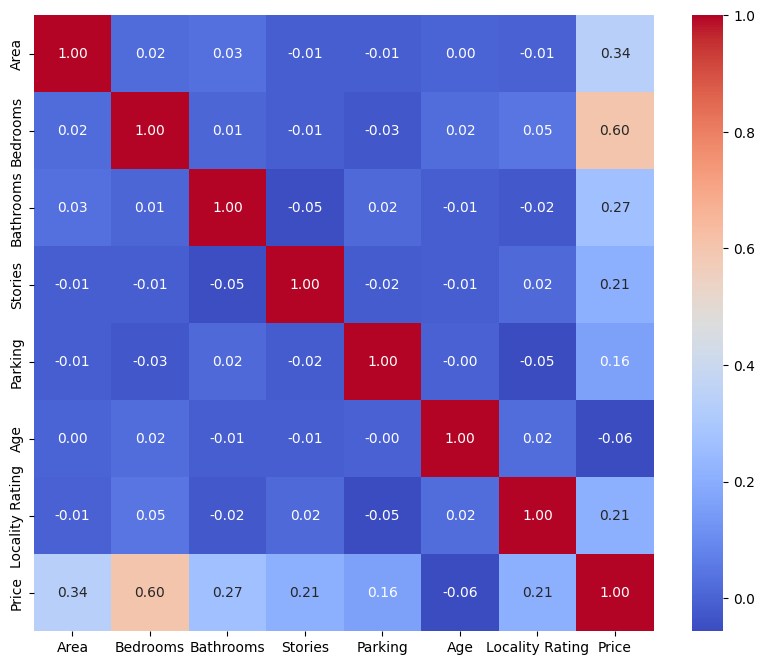

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap='coolwarm',fmt='.2f')

In [ ]:
corr = df.corr()
print(corr['Price'].sort_values(ascending=False))

ValueError: could not convert string to float: 'Pune'

# Data Preprocessing

1. Encoding

2. Scaling

In [ ]:
from sklearn.preprocessing import OrdinalEncoder
oe = ['Furnishing','Main Road','Guest Room','Basement','Air Conditioning']
encoder = OrdinalEncoder(categories=[
    ['Unfurnished','Semi-Furnished','Furnished'],
    ['No','Yes'],
    ['No','Yes'],
    ['No','Yes'],
    ['No','Yes']
])
df[oe] = encoder.fit_transform(df[oe]).astype(int)

In [ ]:
cols = ['City','Water Supply','Preferred Tenant']
df = pd.get_dummies(df,columns=cols,dtype=int)

In [ ]:
df

,Area,Bedrooms,Bathrooms,Stories,Parking,Age,Furnishing,Main Road,Guest Room,Basement,...,City_Hyderabad,City_Kolkata,City_Mumbai,City_Pune,Water Supply_Borewell,Water Supply_Both,Water Supply_Corporation,Preferred Tenant_Bachelor,Preferred Tenant_Company,Preferred Tenant_Family
0,1260,4,3,2,1,24,1,1,1,1,...,0,0,0,1,0,1,0,0,1,0
1,5790,2,1,1,1,7,0,1,1,1,...,0,1,0,0,0,1,0,1,0,0
2,5626,5,2,3,0,15,1,0,1,1,...,0,0,0,0,0,0,1,0,1,0
3,5591,1,1,1,1,47,2,1,0,1,...,0,0,0,0,1,0,0,0,1,0
4,4172,5,1,1,1,44,0,0,0,0,...,0,0,0,0,1,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,4323,1,1,2,0,23,0,1,1,0,...,0,1,0,0,1,0,0,0,1,0
1996,4803,4,2,1,1,8,2,0,0,1,...,0,1,0,0,0,1,0,0,1,0
1997,5855,5,2,3,0,6,2,0,1,0,...,0,1,0,0,1,0,0,1,0,0
1998,2369,3,3,2,2,15,2,1,0,1,...,0,0,0,0,0,1,0,0,0,1


In [ ]:
print(df.T.duplicated())

Area                         False
Bedrooms                     False
Bathrooms                    False
Stories                      False
Parking                      False
Age                          False
Furnishing                   False
Main Road                    False
Guest Room                   False
Basement                     False
Air Conditioning             False
Locality Rating              False
Price                        False
City_Bangalore               False
City_Chennai                 False
City_Delhi                   False
City_Hyderabad               False
City_Kolkata                 False
City_Mumbai                  False
City_Pune                    False
Water Supply_Borewell        False
Water Supply_Both            False
Water Supply_Corporation     False
Preferred Tenant_Bachelor    False
Preferred Tenant_Company     False
Preferred Tenant_Family      False
dtype: bool


In [ ]:
df['Age'].describe()

,Age
count,2000.000000
mean,24.008500
std,14.319076
min,0.000000
25%,12.000000
50%,24.000000
75%,36.000000
max,49.000000


In [ ]:
X = df.drop('Price',axis=1)
Y = df['Price']

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=42)

In [ ]:
from sklearn.preprocessing import RobustScaler
#cols_to_scale = ['Area','Bedrooms','Bathrooms','Stories','Age','Locality Rating']
scaler = RobustScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
X_train[cols_to_scale][['Bedrooms']].describe()

,Bedrooms
count,1600.000000
mean,0.516875
std,0.355027
min,0.000000
25%,0.250000
50%,0.500000
75%,0.750000
max,1.000000


In [ ]:
X_train['Locality Rating'].describe()

,Locality Rating
count,1600.000000
mean,0.485139
std,0.315366
min,0.000000
25%,0.222222
50%,0.444444
75%,0.777778
max,1.000000


In [ ]:
df

,Area,Bedrooms,Bathrooms,Stories,Parking,Age,Furnishing,Main Road,Guest Room,Basement,...,City_Hyderabad,City_Kolkata,City_Mumbai,City_Pune,Water Supply_Borewell,Water Supply_Both,Water Supply_Corporation,Preferred Tenant_Bachelor,Preferred Tenant_Company,Preferred Tenant_Family
0,1260,4,3,2,1,24,1,1,1,1,...,0,0,0,1,0,1,0,0,1,0
1,5790,2,1,1,1,7,0,1,1,1,...,0,1,0,0,0,1,0,1,0,0
2,5626,5,2,3,0,15,1,0,1,1,...,0,0,0,0,0,0,1,0,1,0
3,5591,1,1,1,1,47,2,1,0,1,...,0,0,0,0,1,0,0,0,1,0
4,4172,5,1,1,1,44,0,0,0,0,...,0,0,0,0,1,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,4323,1,1,2,0,23,0,1,1,0,...,0,1,0,0,1,0,0,0,1,0
1996,4803,4,2,1,1,8,2,0,0,1,...,0,1,0,0,0,1,0,0,1,0
1997,5855,5,2,3,0,6,2,0,1,0,...,0,1,0,0,1,0,0,1,0,0
1998,2369,3,3,2,2,15,2,1,0,1,...,0,0,0,0,0,1,0,0,0,1


# Model Building

Linear Regression

In [ ]:
from sklearn.linear_model import LinearRegression
LR = LinearRegression()
LR.fit(X_train,Y_train)

LinearRegression()

In [ ]:
X_test

array([[-0.71936398, -1.        ,  0.5       , ...,  1.        ,
         0.        ,  0.        ],
       [ 0.41816686, -0.5       ,  0.5       , ...,  0.        ,
         0.        ,  1.        ],
       [ 0.48359682,  0.5       , -0.5       , ...,  1.        ,
         0.        ,  0.        ],
       ...,
       [-1.00667093, -1.        , -0.5       , ...,  1.        ,
         0.        ,  0.        ],
       [ 0.59544915,  1.        ,  0.5       , ...,  0.        ,
         1.        ,  0.        ],
       [ 0.81659508,  0.5       ,  0.5       , ...,  0.        ,
         0.        ,  1.        ]])

In [ ]:
y_predict = LR.predict(X_test)

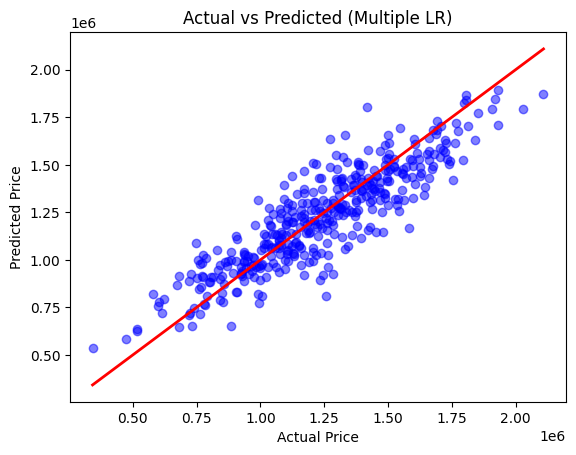

In [ ]:
plt.scatter(Y_test, y_predict, color='blue', alpha=0.5)
plt.plot([Y_test.min(), Y_test.max()],
         [Y_test.min(), Y_test.max()],
         color='red', linewidth=2)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted (Multiple LR)")
plt.show()

In [ ]:
y_predict

array([ 986650.08960554, 1380785.93256165, 1377612.26445063,
        808459.60121103, 1000503.03328301, 1128570.20306364,
       1389540.45423192, 1266130.1535696 ,  768295.25970387,
       1661973.15640835, 1396180.51592125, 1181457.727955  ,
       1299333.25034325, 1235719.2678613 , 1287835.06818086,
       1027257.03924675, 1050467.95389485, 1412854.53173169,
        626160.60167066, 1365460.32531793, 1263963.35685841,
        760135.51955511, 1254024.92600372, 1027668.85707505,
        989800.99746311,  967357.35154731,  988889.99920285,
       1024239.62587206, 1342628.1200333 ,  997834.77351079,
       1842646.51672925, 1433043.75534435, 1294299.89140136,
       1091576.69776347, 1021201.67914596, 1155149.81342902,
        847920.34557231, 1365654.12715754, 1173901.07156171,
       1165694.88323491, 1154960.70527585, 1410361.79121415,
       1098700.27817753,  983213.31541231,  961229.11538524,
       1496236.26920221, 1029112.91727855, 1450757.4481967 ,
       1264428.41201468,

In [ ]:
from sklearn.metrics import r2_score, mean_squared_error , mean_absolute_error , root_mean_squared_error
r2_score = r2_score(Y_test,y_predict)
print("R2_Score : " , r2_score)
mse = mean_squared_error(Y_test,y_predict)
print("MSE : " , mse)
mae = mean_absolute_error(Y_test,y_predict)
print("MAE : " , mae)
rmse = root_mean_squared_error(Y_test,y_predict)
print("RMSE : " , rmse)

R2_Score :  0.7775261417077477
MSE :  20165469519.349655
MAE :  111901.16382488627
RMSE :  142005.17426963587


Normal Residuals

In [ ]:
residual = Y_test - y_predict
residual

,Price
1860,-50583.089606
353,-52944.932562
1333,58525.735549
905,450077.398789
1289,-113738.033283
...,...
965,200895.951327
1284,47803.114632
1739,185390.867996
261,107465.036437


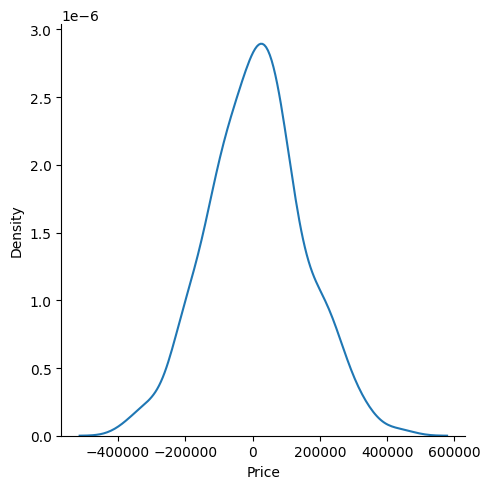

In [ ]:
#using kde to check it is normally distributed
sns.displot(residual,kind='kde')

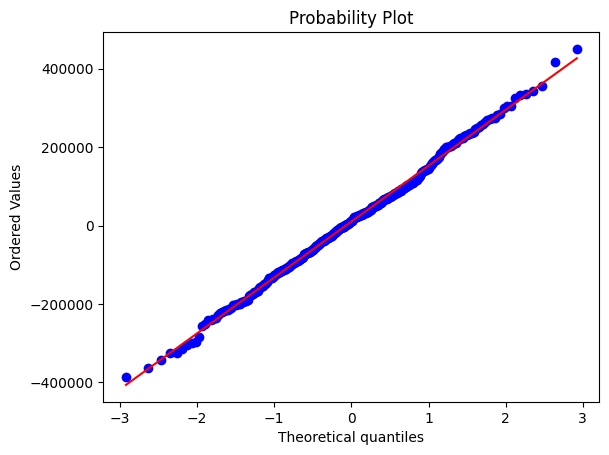

In [ ]:
#using QO Plot
import scipy as sp
sp.stats.probplot(residual, dist="norm", plot=plt)
plt.show()

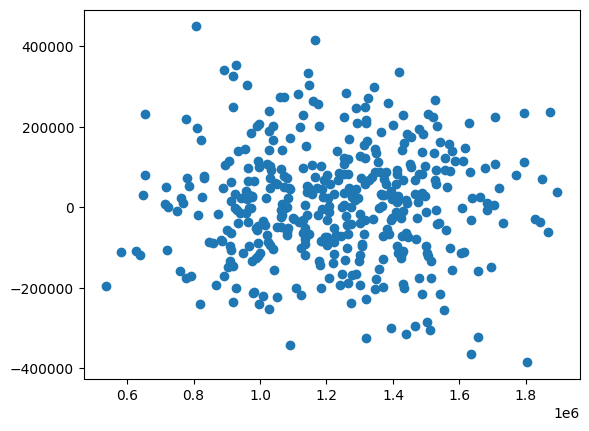

In [ ]:
plt.scatter(y_predict,residual) `1

No Autocollineaity

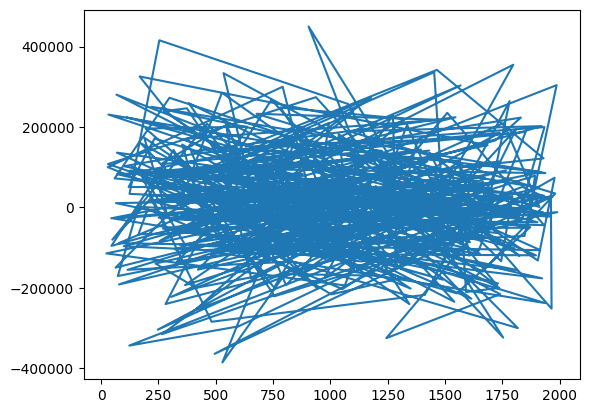

In [ ]:
plt.plot(residual)

In [ ]:
train_score = LR.score(X_train, Y_train)
test_score  = LR.score(X_test, Y_test)
print(f"Train R²: {train_score:.4f}")
print(f"Test R² : {test_score:.4f}")

Train R²: 0.7437
Test R² : 0.7775


In [ ]:
b = LR.coef_
b

array([ 3.28647874e+05,  4.96690574e+05,  1.82345532e+05,  1.68030283e+05,
        6.91263404e+04, -8.30625326e+04,  8.22233110e+04,  5.54573822e+04,
        5.33722153e+04,  5.40133093e+04,  9.03619507e+04,  1.82437402e+05,
       -5.24303358e+01,  7.20872723e+03, -4.20653542e+03,  9.50756188e+03,
       -2.92246118e+03,  2.70915468e+03, -1.22440168e+04,  8.00525688e+03,
       -1.17454434e+04,  3.74018653e+03,  1.13107102e+02, -3.32916696e+03,
        3.21605986e+03])

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
param_grid = {
    'n_estimators': [100, 200, 500, 300],
    'max_depth': [10, 15, None],
    'max_samples': [0.5, 0.75, 0.8, 0.9],
    'criterion': ['squared_error'],
    'max_features': ['sqrt', 0.4, 0.6]  # <-- FIXED: changed "0, 6" to "0.6"
}

model = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='r2'
)
model.fit(X_train,Y_train)

GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42),
             param_grid={'criterion': ['squared_error'],
                         'max_depth': [10, 15, None],
                         'max_features': ['sqrt', 0.4, 0.6],
                         'max_samples': [0.5, 0.75, 0.8, 0.9],
                         'n_estimators': [100, 200, 500, 300]},
             scoring='r2')

In [ ]:
y_predict3 = model.predict(X_test)
y_predict3

array([ 937360.78264706, 1186122.59594921, 1382565.239     ,
        867852.56733333, 1083519.56931429, 1347802.06899936,
       1290275.6169    , 1349597.307025  ,  911663.67393333,
       1627485.802     , 1264582.47139091, 1322553.42853333,
       1330861.4903    , 1173550.2408873 , 1323161.06492778,
       1038981.012     , 1018103.63466667, 1440765.76047619,
        792695.512     , 1316206.64175   , 1349046.35461111,
        900044.5606    , 1187499.5       , 1055037.13965758,
       1049670.90747576, 1043424.80766667, 1151106.2416    ,
       1120810.38973333, 1420125.6256    , 1026326.9607    ,
       1753658.17072727, 1471486.70771429, 1379871.39704848,
       1107783.84136667,  995398.07383333, 1214959.7587    ,
        929513.24936111, 1389324.80904127, 1276752.98091667,
       1276997.64561818, 1071936.699     , 1453234.7587619 ,
       1154305.33833175, 1053546.4855    , 1073567.67053333,
       1502078.01629444, 1120332.53179762, 1326479.50822424,
       1415568.9045381 ,

In [ ]:
from sklearn.metrics import r2_score
print("R2 Score : ",r2_score(Y_test,y_predict3))

R2 Score :  0.6974429288507131
